In [ ]:
import os

print(os.listdir("/content"))

['.config', '.gradio', '.ipynb_checkpoints', 'Weather-Analysis-main (5).zip', 'weather_dataset', 'sample_data']


In [ ]:
import os

print(os.listdir("/content/weather_dataset"))

['Weather-Analysis-main']


In [ ]:
import os

print(os.listdir("/content/weather_dataset/Weather-Analysis-main"))

['.DS_Store', 'pl_logo.png', 'shine', 'rain', 'sunrise', 'README.md', 'weather_new_log.csv', 'cloud']


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/weather_dataset/Weather-Analysis-main",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/weather_dataset/Weather-Analysis-main",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print(train_ds.class_names)

Found 1123 files belonging to 4 classes.
Using 899 files for training.
Found 1123 files belonging to 4 classes.
Using 224 files for validation.
['cloud', 'rain', 'shine', 'sunrise']


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7597 - loss: 0.6637 - val_accuracy: 0.8973 - val_loss: 0.2947
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9333 - loss: 0.2071 - val_accuracy: 0.9241 - val_loss: 0.2198
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9611 - loss: 0.1269 - val_accuracy: 0.9241 - val_loss: 0.1956
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9655 - loss: 0.1037 - val_accuracy: 0.9286 - val_loss: 0.1930
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9833 - loss: 0.0746 - val_accuracy: 0.9196 - val_loss: 0.1854
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9878 - loss: 0.0575 - val_accuracy: 0.9152 - val_loss: 0.1806
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9855 - loss: 0.0485 - val_accuracy: 0.9330 - val_loss: 0.1862
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9755 - loss: 0.0744 - val_accuracy: 0.9420 - val_loss:

In [ ]:
model.save("/content/weather_mobilenet_model.keras")
print("Model Saved Successfully!")

Model Saved Successfully!


Saving cloud_0.jpeg to cloud_0.jpeg


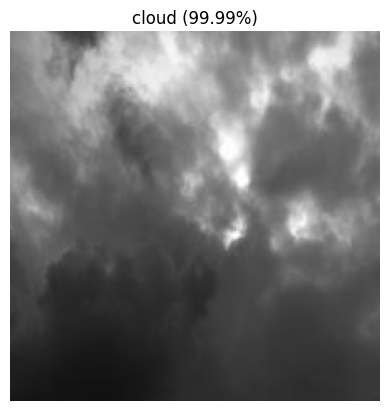

Prediction: cloud
Confidence: 99.98894


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload one image
uploaded = files.upload()

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

class_names = ['cloud', 'rain', 'shine', 'sunrise']

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

Saving shine_0.jpeg to shine_0.jpeg


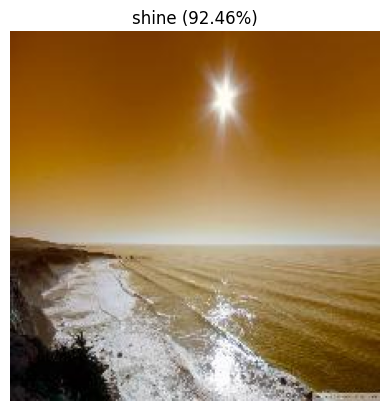

Prediction: shine
Confidence: 92.46499


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload one image
uploaded = files.upload()

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

class_names = ['cloud', 'rain', 'shine', 'sunrise']

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

Saving sunrise_0.jpeg to sunrise_0.jpeg


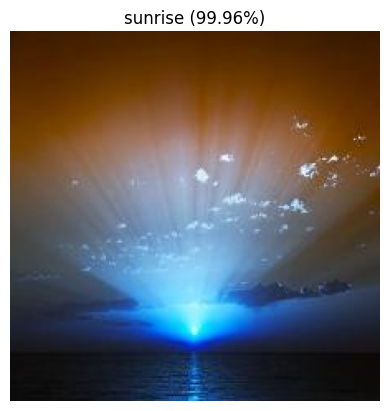

Prediction: sunrise
Confidence: 99.95616


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload one image
uploaded = files.upload()

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

class_names = ['cloud', 'rain', 'shine', 'sunrise']

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

Saving rain_0.jpeg to rain_0.jpeg


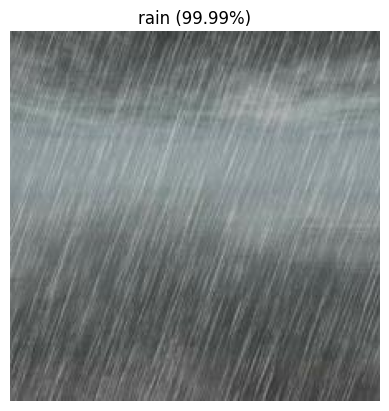

Prediction: rain
Confidence: 99.98927


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload one image
uploaded = files.upload()

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

class_names = ['cloud', 'rain', 'shine', 'sunrise']

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

Saving rain_10.jpeg to rain_10.jpeg


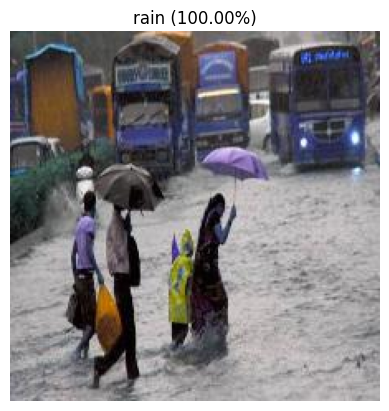

Prediction: rain
Confidence: 99.99917


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload one image
uploaded = files.upload()

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

class_names = ['cloud', 'rain', 'shine', 'sunrise']

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

Saving sunrise_1.jpeg to sunrise_1.jpeg


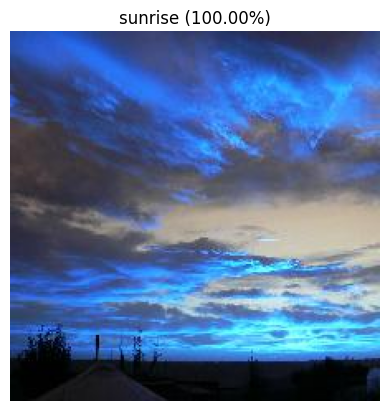

Prediction: sunrise
Confidence: 99.99837


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload one image
uploaded = files.upload()

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

class_names = ['cloud', 'rain', 'shine', 'sunrise']

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)